# Negative Binomial Model Attempt

## Read in data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/eagles_modeling_df.csv", index_col=0)
df

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,ConfChamp,SuperBowl,gameday,start_hour,end_hour,game_period,baseline,percent_change_in_stops,area_km2,stop_density
0,2014-09-07,0,1,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1,13,16,before,0.117093,-1.000000,3.141593,0.000000
1,2014-09-07,0,2,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1,13,16,before,0.488560,-1.000000,9.424778,0.000000
2,2014-09-07,0,3,1,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1,13,16,before,1.687752,-0.407496,15.707963,0.063662
3,2014-09-07,0,4,14,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1,13,16,before,2.969044,3.715322,21.991149,0.636620
4,2014-09-07,0,5,3,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1,13,16,before,2.618439,0.145721,28.274334,0.106103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-02-04,23,1,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,1.0,1,18,22,after,0.056528,-1.000000,3.141593,0.000000
8036,2018-02-04,23,2,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,1.0,1,18,22,after,0.436743,-1.000000,9.424778,0.000000
8037,2018-02-04,23,3,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,1.0,1,18,22,after,1.556528,-1.000000,15.707963,0.000000
8038,2018-02-04,23,4,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,1.0,1,18,22,after,2.187079,-1.000000,21.991149,0.000000


## Remove Extra Columns

In [3]:
df.drop(columns=['stop_count', 'Opp', 'TeamScore', 'OppScore', 'DefTO', 'OffTO', 'Wins', 'Losses','Giants', 'Cowboys',
                 'gameday', 'baseline', 'percent_change_in_stops', 'area_km2'], inplace=True)
df.columns

Index(['date', 'hour', 'region', 'Game', 'Day', 'StartTime', 'xEndTime',
       'Home', 'PointDiff', 'TODiff', 'Win', 'OT', 'Season', 'Streak',
       'Rivalry', 'RegularSeason', 'Division', 'ConfChamp', 'SuperBowl',
       'start_hour', 'end_hour', 'game_period', 'stop_density'],
      dtype='object')

In [4]:
df

,date,hour,region,Game,Day,StartTime,xEndTime,Home,PointDiff,TODiff,...,Streak,Rivalry,RegularSeason,Division,ConfChamp,SuperBowl,start_hour,end_hour,game_period,stop_density
0,2014-09-07,0,1,1,Sunday,13:02:00,16:14:00,0.0,17.0,-2.0,...,1.0,0.0,1.0,0.0,0.0,0.0,13,16,before,0.000000
1,2014-09-07,0,2,1,Sunday,13:02:00,16:14:00,0.0,17.0,-2.0,...,1.0,0.0,1.0,0.0,0.0,0.0,13,16,before,0.000000
2,2014-09-07,0,3,1,Sunday,13:02:00,16:14:00,0.0,17.0,-2.0,...,1.0,0.0,1.0,0.0,0.0,0.0,13,16,before,0.063662
3,2014-09-07,0,4,1,Sunday,13:02:00,16:14:00,0.0,17.0,-2.0,...,1.0,0.0,1.0,0.0,0.0,0.0,13,16,before,0.636620
4,2014-09-07,0,5,1,Sunday,13:02:00,16:14:00,0.0,17.0,-2.0,...,1.0,0.0,1.0,0.0,0.0,0.0,13,16,before,0.106103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-02-04,23,1,SuperBowl,Sunday,18:30:00,21:42:00,0.0,8.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,18,22,after,0.000000
8036,2018-02-04,23,2,SuperBowl,Sunday,18:30:00,21:42:00,0.0,8.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,18,22,after,0.000000
8037,2018-02-04,23,3,SuperBowl,Sunday,18:30:00,21:42:00,0.0,8.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,18,22,after,0.000000
8038,2018-02-04,23,4,SuperBowl,Sunday,18:30:00,21:42:00,0.0,8.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,18,22,after,0.000000


## Variable distributions

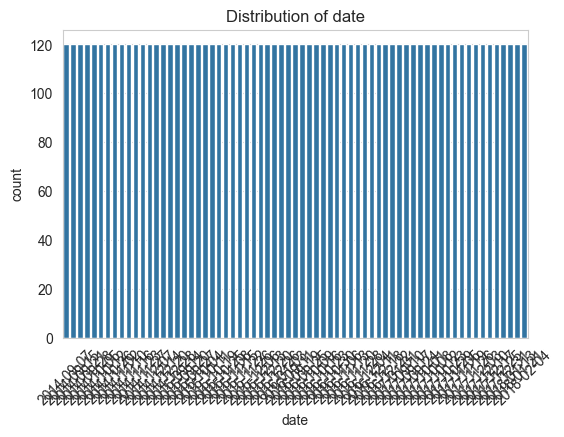

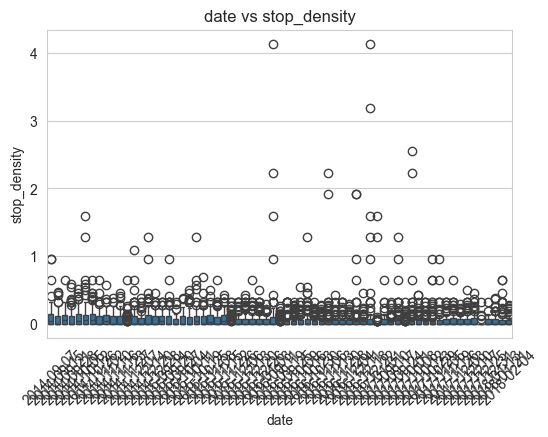

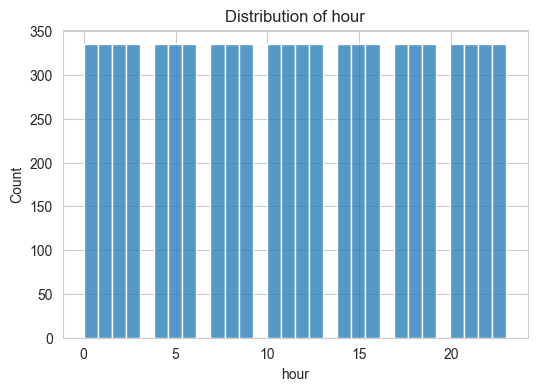

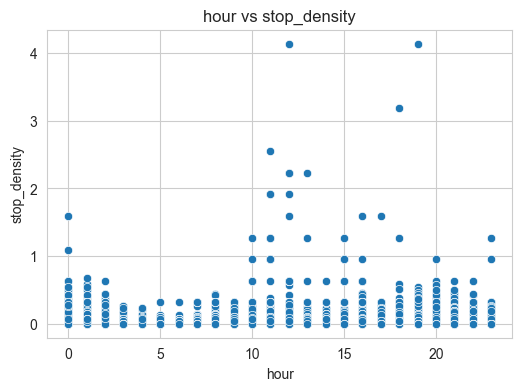

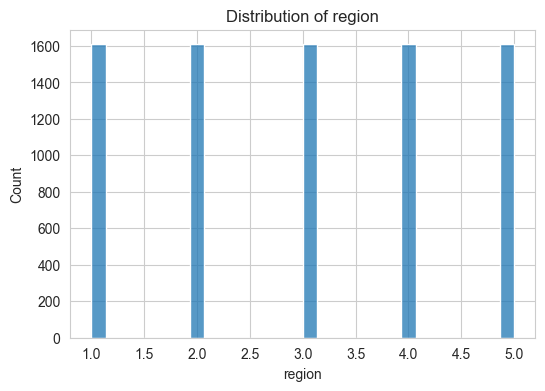

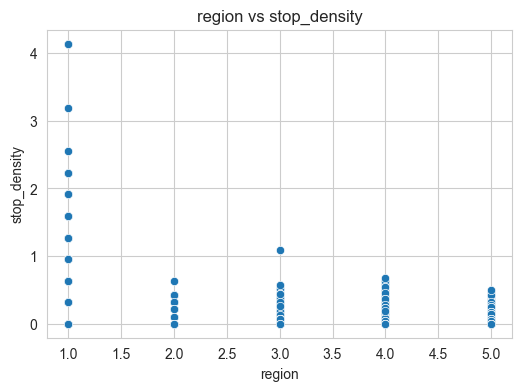

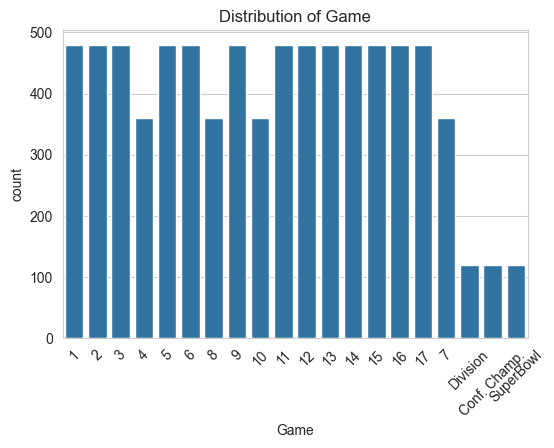

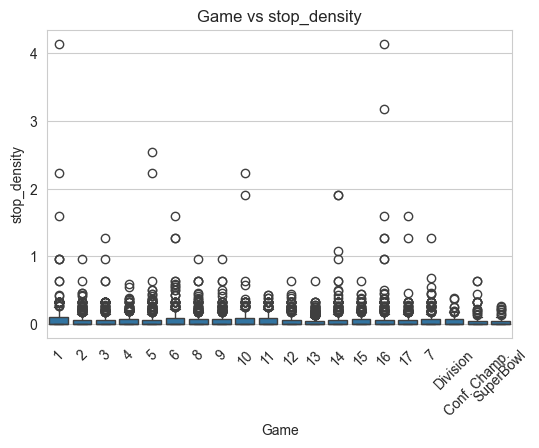

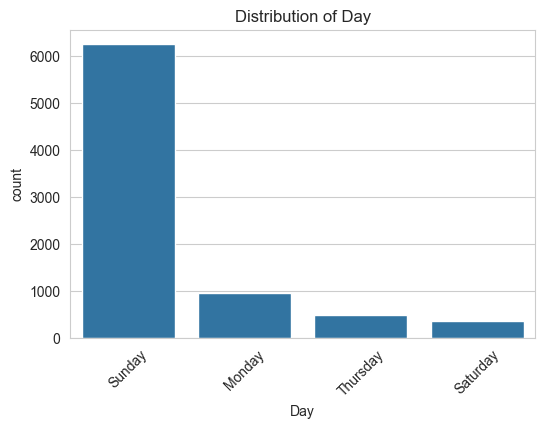

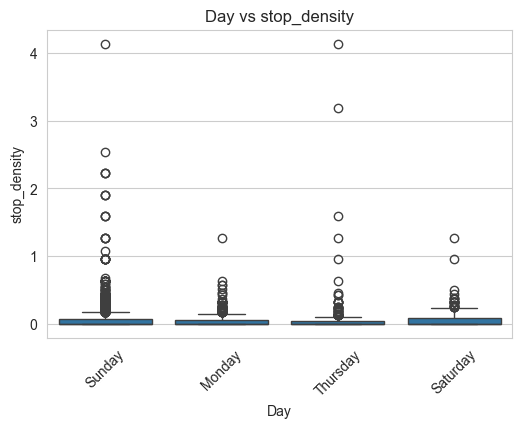

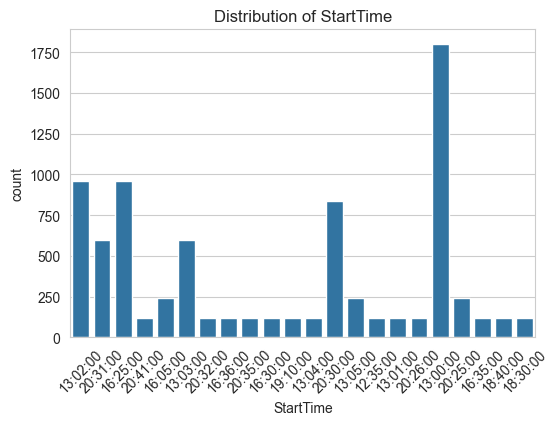

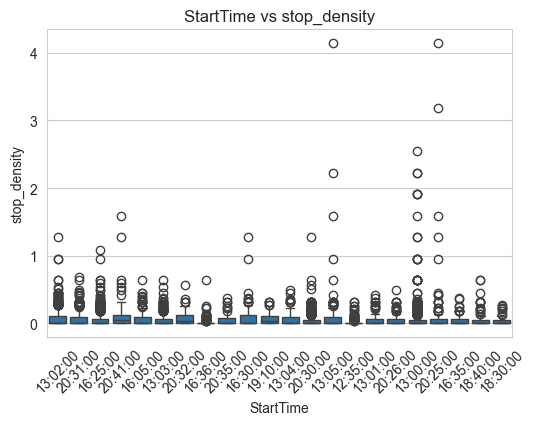

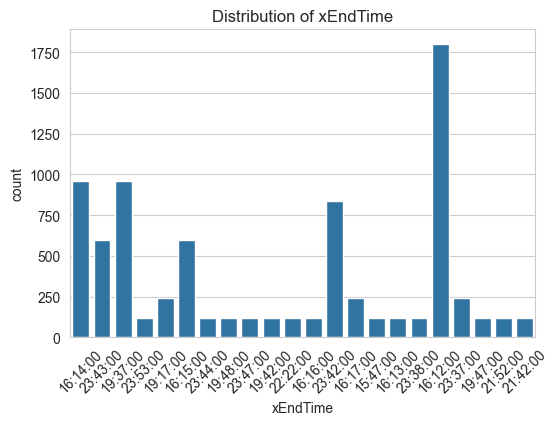

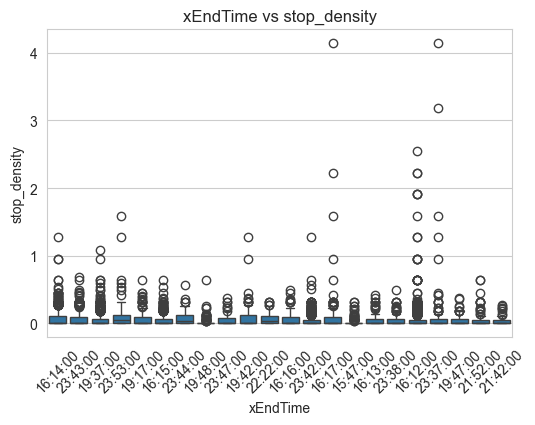

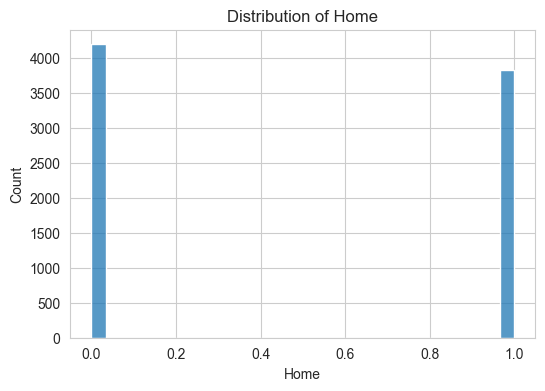

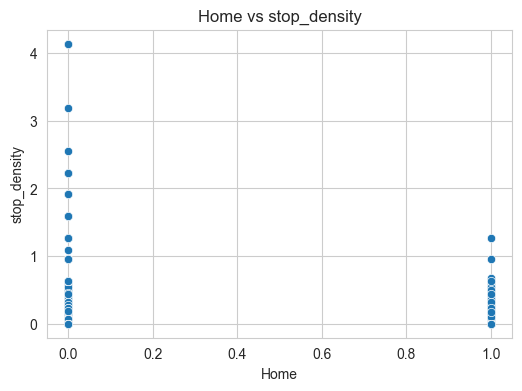

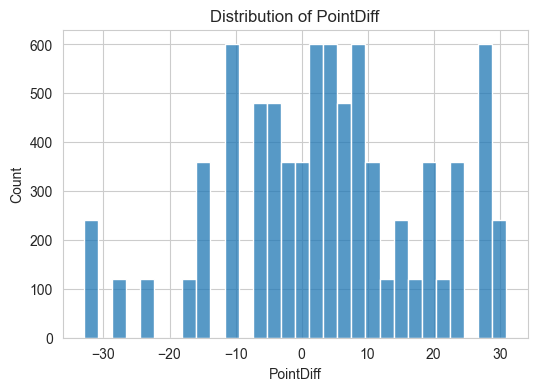

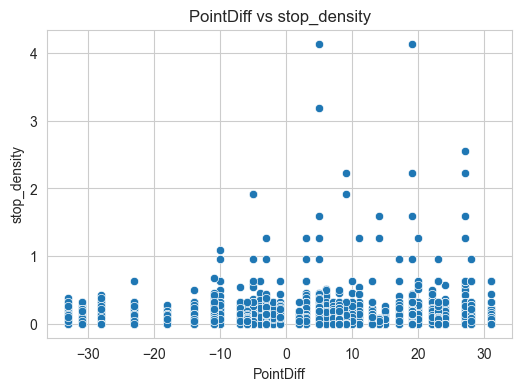

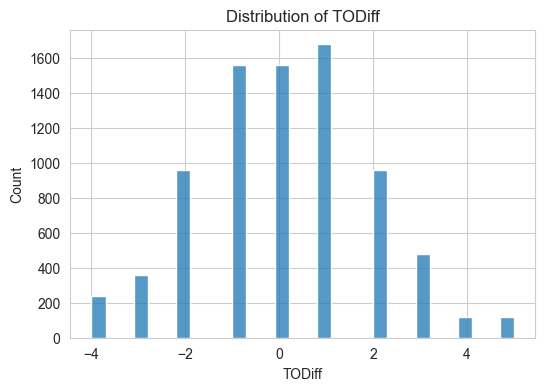

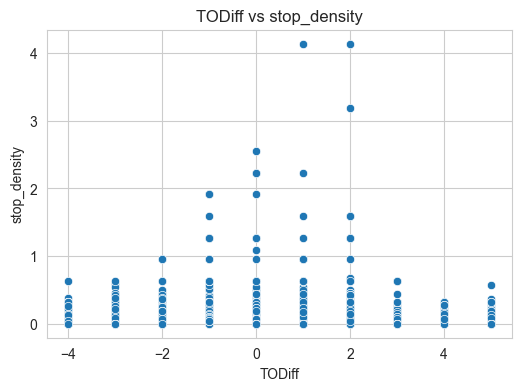

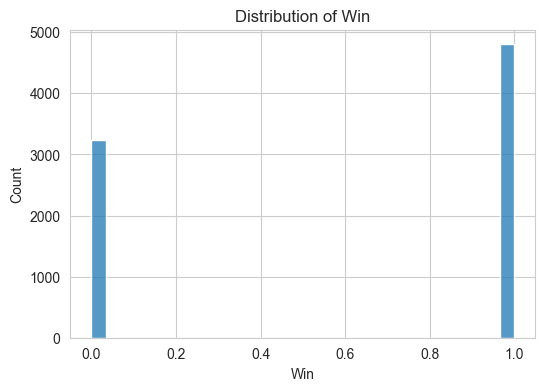

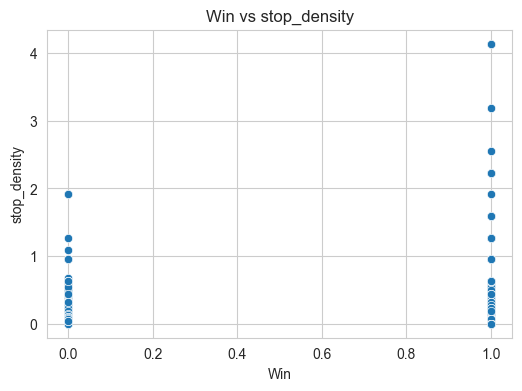

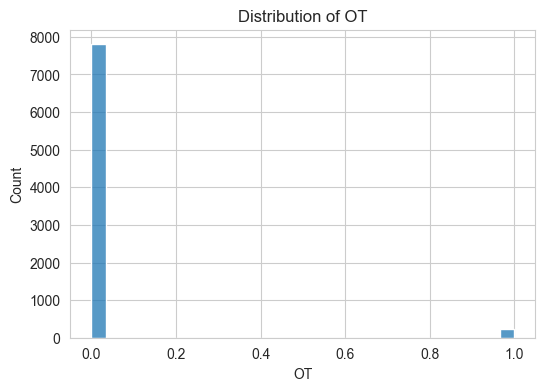

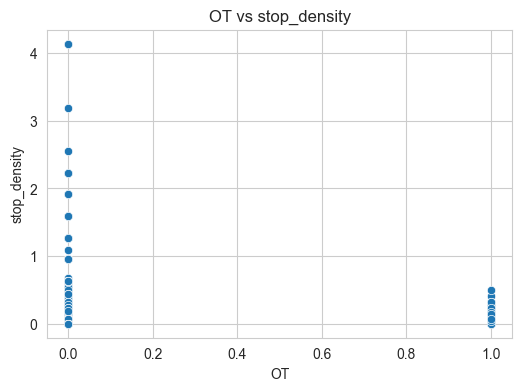

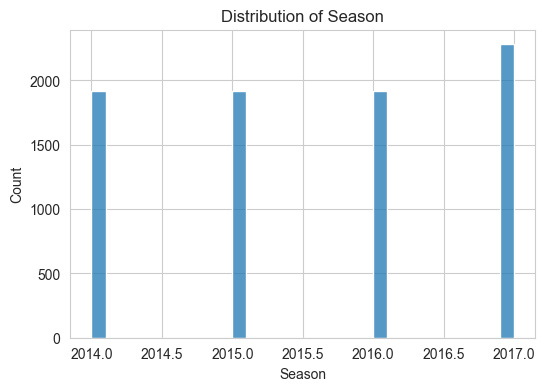

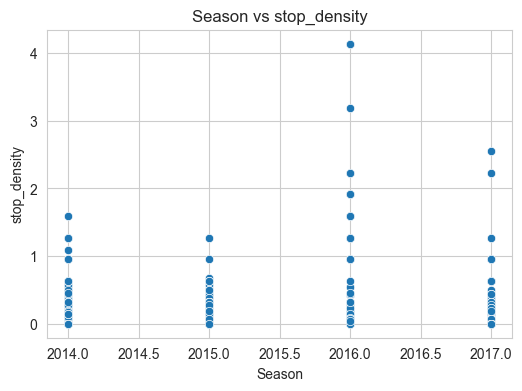

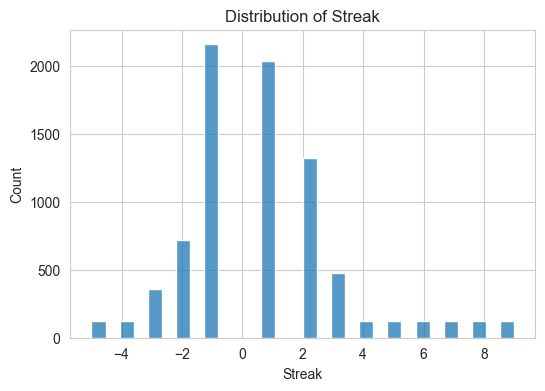

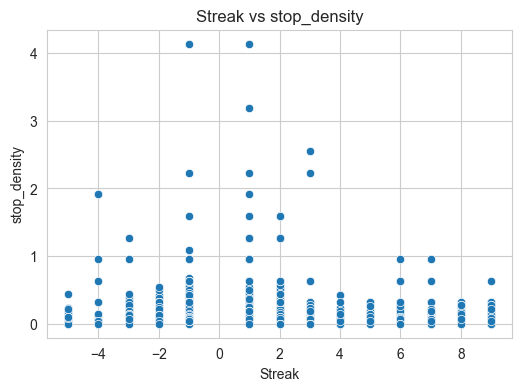

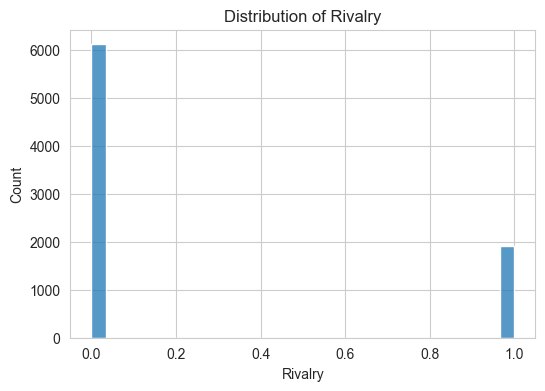

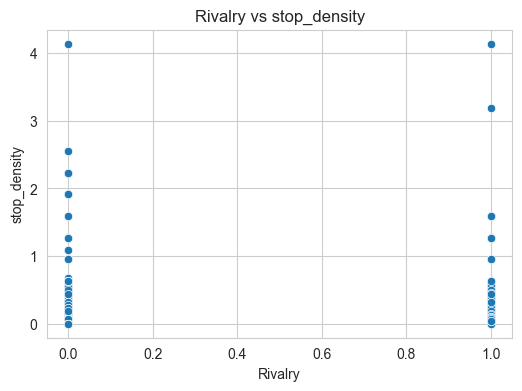

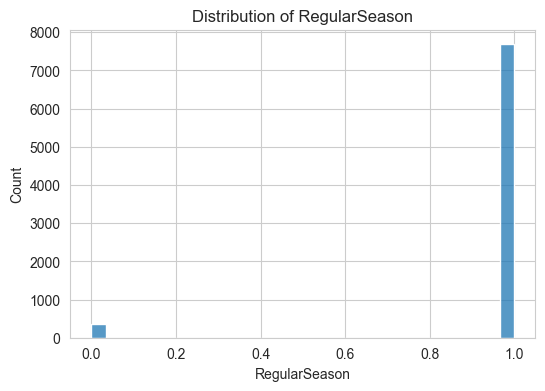

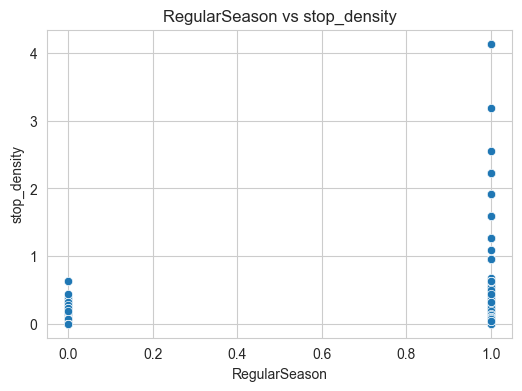

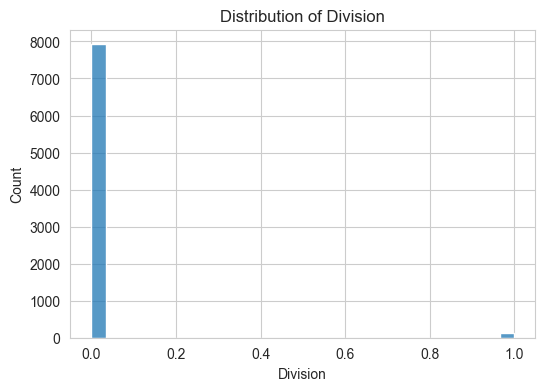

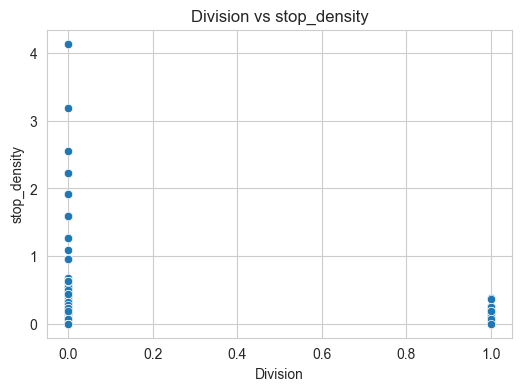

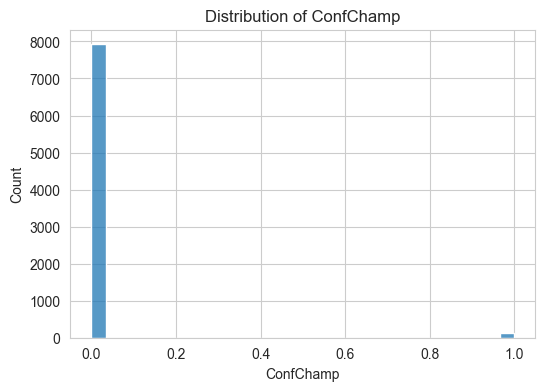

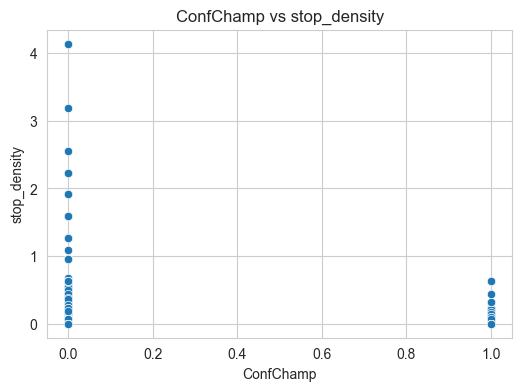

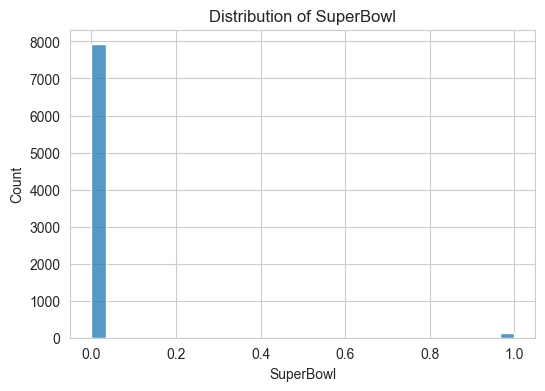

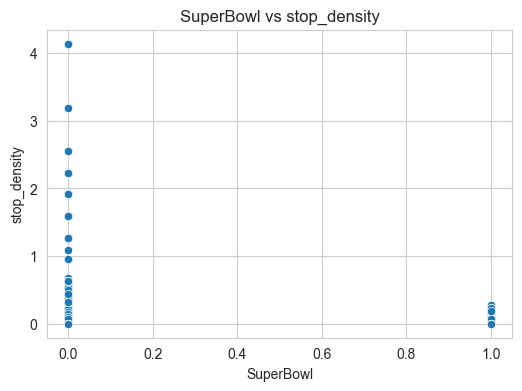

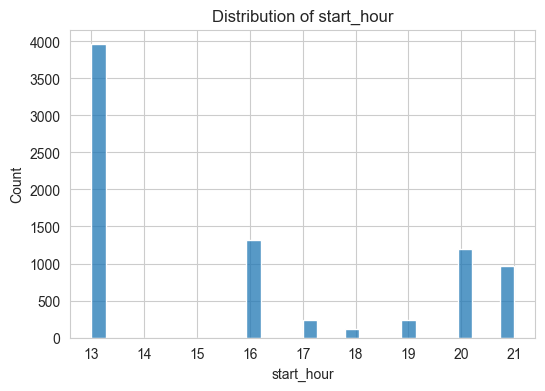

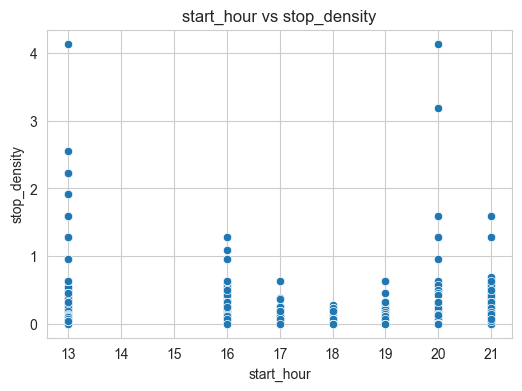

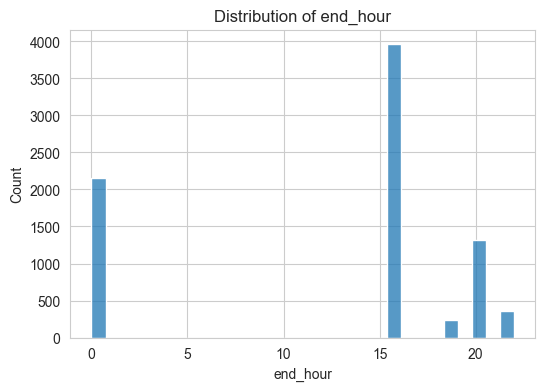

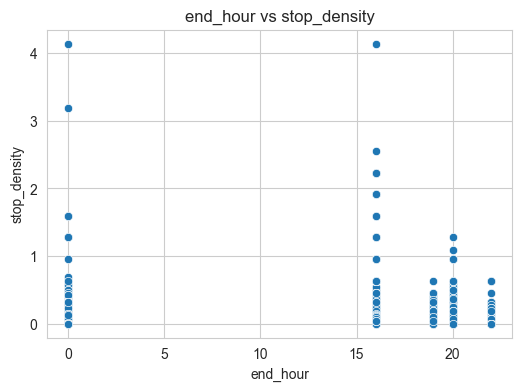

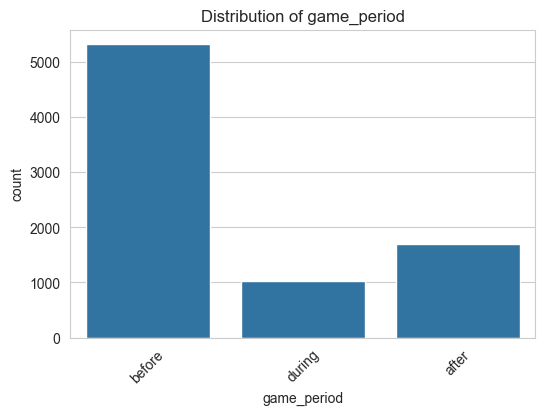

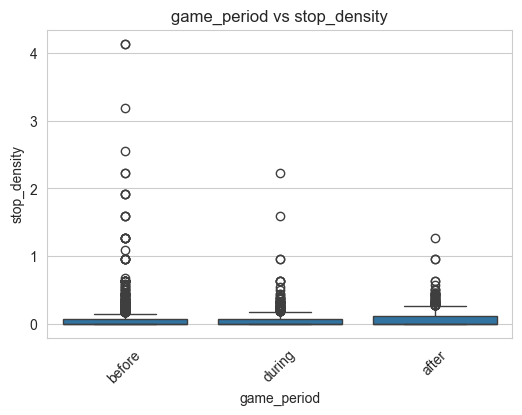

In [5]:
target = 'stop_density'

features = [col for col in df.columns if col != target]

for col in features:

    # -------- Distribution Plot --------
    plt.figure(figsize=(6,4))

    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(df[col], bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)

    else:
        sns.countplot(x=df[col])
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)

    plt.show()


    # -------- Feature vs Target --------
    plt.figure(figsize=(6,4))

    if pd.api.types.is_numeric_dtype(df[col]):
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f'{col} vs {target}')

    else:
        sns.boxplot(x=df[col], y=df[target])
        plt.title(f'{col} vs {target}')
        plt.xticks(rotation=45)

    plt.show()


## Outlier removal

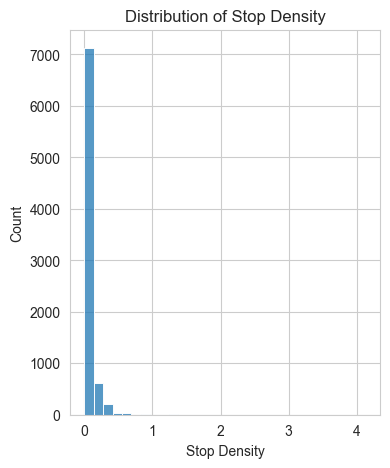

In [6]:
fig, ax = plt.subplots(figsize=(4, 5))

# Create the plot, passing the ax object
#sns.scatterplot(x="total_bill", y="tip", data=tips, ax=ax)
sns.histplot(df['stop_density'], bins=30, ax=ax)
plt.title(f'Distribution of Stop Density')
plt.xlabel('Stop Density')
plt.show()

In [7]:
df['stop_density'].sort_values(ascending=False)

5615    4.138029
3900    4.138029
5610    3.183099
6295    2.546479
4860    2.228169
          ...   
3621    0.000000
3620    0.000000
3618    0.000000
3617    0.000000
8039    0.000000
Name: stop_density, Length: 8040, dtype: float64

## Prep and model data

In [8]:
# Convert 'StartTime' and 'xEndTime' strings to integers
df['StartHour'] = df['StartTime'].astype(str).str.split(':').str[0].astype(int)
df['EndHour'] = df['xEndTime'].astype(str).str.split(':').str[0].astype(int)

# Now these are 0-23 integers, and XGBoost will love them!
features = [
    'hour', 'region', 'Day', 'Home',
    'PointDiff', 'TODiff', 'Win', 'OT', 'Season', 'Streak',
    'Rivalry', 'RegularSeason', 'Division', 'ConfChamp',
    'SuperBowl', 'start_hour', 'end_hour', 'game_period'
]

X = df[features].copy()
y = df['stop_density']

# Convert categorical text/objects into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['region', 'Day', 'Season', 'game_period'],
                   drop_first=True,
                   dtype=int)

In [9]:
from sklearn.model_selection import GroupShuffleSplit

# Create a unique ID for each date + hour
df['group_id'] = df['date'].astype(str) + "_" + df['hour'].astype(str)

# Use GroupShuffleSplit instead of regular train_test_split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['group_id']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [10]:
X_train

,hour,Home,PointDiff,TODiff,Win,OT,Streak,Rivalry,RegularSeason,Division,...,region_4,region_5,Day_Saturday,Day_Sunday,Day_Thursday,Season_2015.0,Season_2016.0,Season_2017.0,game_period_before,game_period_during
0,0,0.0,17.0,-2.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0,0,0,1,0,0,0,0,1,0
1,0,0.0,17.0,-2.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0,0,0,1,0,0,0,0,1,0
2,0,0.0,17.0,-2.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0,0,0,1,0,0,0,0,1,0
3,0,0.0,17.0,-2.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1,0,0,1,0,0,0,0,1,0
4,0,0.0,17.0,-2.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,23,0.0,8.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0,1,0,0
8036,23,0.0,8.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0,1,0,0
8037,23,0.0,8.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0,1,0,0
8038,23,0.0,8.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,...,1,0,0,1,0,0,0,1,0,0


In [11]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, mean_tweedie_deviance
from sklearn.metrics import r2_score

# use 'reg:tweedie' to handle that zero-inflated density distribution
model = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5, # Balance between Poisson (0s) and Gamma (tails)
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,                # Shallow trees prevent overfitting to noise
    subsample=0.7,
    colsample_bytree=0.8,
    random_state=42
)

# This stops training when the test error stops improving for 50 rounds
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# predictions
preds = model.predict(X_test)

# Evaluate
rmse = root_mean_squared_error(y_test, preds)
# Tweedie Deviance is a better metric than MSE for this specific distribution
#deviance = mean_tweedie_deviance(y_test, preds, power=1.5)

r2 = r2_score(y_test, preds)

print(f"Standard R^2 Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
#print(f"Tweedie Deviance: {deviance:.4f}")

Standard R^2 Score: 0.1147
Root Mean Squared Error: 0.1520


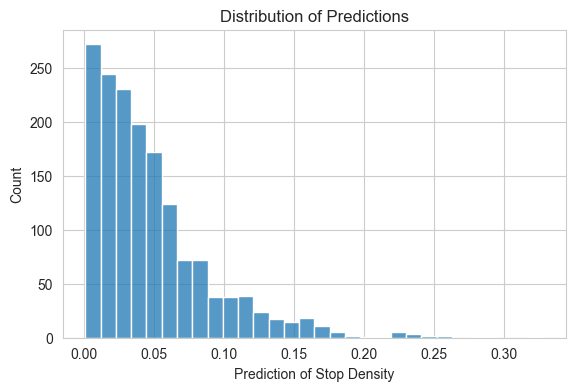

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4))

sns.histplot(preds, bins=30, ax=ax)
plt.title(f'Distribution of Predictions')
plt.xlabel('Prediction of Stop Density')
plt.show()